<a href="https://colab.research.google.com/github/funzi-son/plant_pathology_dl/blob/nesy_cons/SemanticLoss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
from google.colab import drive


In [ ]:
drive.mount('/content/drive')

train_dir =  "/content/drive/MyDrive/PlantDoc2.0/train"
test_dir = "/content/drive/MyDrive/PlantDoc2.0/test"

# Image transforms
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

# Split train into train (70%) and val (10%) → rest test (20% already provided)
train_size = int(0.875 * len(train_dataset))  # 70 / (70+10)
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# DataLoaders
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
class MultiOutputCNN(nn.Module):
    def __init__(self, num_species, num_diseases):
        super(MultiOutputCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(8),

            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(8)
        )
        self.flatten = nn.Flatten()
        self.species_head = nn.Linear(32 * 2 * 2, num_species)
        self.disease_head = nn.Linear(32 * 2 * 2, num_diseases)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        species = F.softmax(self.species_head(x), dim=1)
        disease = F.softmax(self.disease_head(x), dim=1)
        return species, disease



In [ ]:
def semantic_loss(logits):
    """
    Vectorized semantic loss enforcing one-hot constraint.
    logits: [batch, num_classes]
    """
    probs = torch.softmax(logits, dim=1)  # [B, C]
    one_hot_prob = torch.sum(probs * torch.prod(1 - probs.unsqueeze(2) + torch.eye(probs.size(1), device=probs.device), dim=1), dim=1)
    loss = -torch.log(one_hot_prob + 1e-8)
    return loss.mean()


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_species = 13   # from dataset
num_diseases = 17  # from dataset

model = MultiOutputCNN(num_species, num_diseases).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Cross-entropy for supervised parts
criterion_species = nn.CrossEntropyLoss()
criterion_disease = nn.CrossEntropyLoss()


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import csv, os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==== SETTINGS ====
SAVE_PATH = "/content/drive/MyDrive/Models/plant_multioutput_semantic.pth"
LOG_PATH  = "/content/drive/MyDrive/Models/training_log.csv"
num_epochs = 200   # reduce, then early stopping
best_val_loss = np.inf

# ==== FASTER SEMANTIC LOSS ====
def semantic_loss(logits):
    """
    Vectorized semantic loss enforcing one-hot constraint.
    logits: [batch, num_classes]
    """
    probs = torch.softmax(logits, dim=1)  # [B, C]
    # Probability of valid one-hot assignment
    one_hot_prob = torch.sum(probs * torch.prod(
        1 - probs.unsqueeze(2) + torch.eye(probs.size(1), device=probs.device), dim=1
    ), dim=1)
    loss = -torch.log(one_hot_prob + 1e-8)
    return loss.mean()

# ==== RESUME CHECKPOINT ====
start_epoch = 0
if os.path.exists(SAVE_PATH):
    checkpoint = torch.load(SAVE_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    print(f"✅ Resumed training from epoch {start_epoch}")

# ==== TRAINING LOOP ====
for epoch in range(start_epoch, num_epochs):
    model.train()
    train_loss = 0.0
    all_sp_true, all_sp_pred = [], []
    all_dis_true, all_dis_pred = [], []

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        sp_logits, dis_logits = model(imgs)

        # Split combined label
        sp_labels = labels % num_species
        dis_labels = labels // num_species

        # Losses
        loss_sp = criterion_species(sp_logits, sp_labels)
        loss_dis = criterion_disease(dis_logits, dis_labels)
        loss_sem_sp = semantic_loss(sp_logits)
        loss_sem_dis = semantic_loss(dis_logits)

        loss = loss_sp + loss_dis + 0.1*(loss_sem_sp + loss_sem_dis)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # Predictions
        all_sp_true.extend(sp_labels.cpu().numpy())
        all_sp_pred.extend(sp_logits.argmax(1).cpu().numpy())
        all_dis_true.extend(dis_labels.cpu().numpy())
        all_dis_pred.extend(dis_logits.argmax(1).cpu().numpy())

    # ---- TRAIN METRICS ----
    sp_acc = accuracy_score(all_sp_true, all_sp_pred)
    sp_prec = precision_score(all_sp_true, all_sp_pred, average="macro", zero_division=0)
    sp_rec = recall_score(all_sp_true, all_sp_pred, average="macro", zero_division=0)
    sp_f1 = f1_score(all_sp_true, all_sp_pred, average="macro", zero_division=0)

    dis_acc = accuracy_score(all_dis_true, all_dis_pred)
    dis_prec = precision_score(all_dis_true, all_dis_pred, average="macro", zero_division=0)
    dis_rec = recall_score(all_dis_true, all_dis_pred, average="macro", zero_division=0)
    dis_f1 = f1_score(all_dis_true, all_dis_pred, average="macro", zero_division=0)

    avg_train_loss = train_loss / len(train_loader)

    # ---- VALIDATION METRICS ----
    model.eval()
    val_loss = 0.0
    val_sp_true, val_sp_pred = [], []
    val_dis_true, val_dis_pred = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            sp_logits, dis_logits = model(imgs)

            sp_labels = labels % num_species
            dis_labels = labels // num_species

            loss_sp = criterion_species(sp_logits, sp_labels)
            loss_dis = criterion_disease(dis_logits, dis_labels)
            loss_sem_sp = semantic_loss(sp_logits)
            loss_sem_dis = semantic_loss(dis_logits)

            loss = loss_sp + loss_dis + 0.1*(loss_sem_sp + loss_sem_dis)
            val_loss += loss.item()

            val_sp_true.extend(sp_labels.cpu().numpy())
            val_sp_pred.extend(sp_logits.argmax(1).cpu().numpy())
            val_dis_true.extend(dis_labels.cpu().numpy())
            val_dis_pred.extend(dis_logits.argmax(1).cpu().numpy())

    avg_val_loss = val_loss / len(test_loader)
    sp_val_acc = accuracy_score(val_sp_true, val_sp_pred)
    dis_val_acc = accuracy_score(val_dis_true, val_dis_pred)

    # ---- PRINT PROGRESS ----
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f" Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f" Species → Train Acc: {sp_acc:.3f}, Val Acc: {sp_val_acc:.3f}")
    print(f" Disease → Train Acc: {dis_acc:.3f}, Val Acc: {dis_val_acc:.3f}")

    # ---- SAVE CHECKPOINT (every 5 epochs) ----
    if (epoch + 1) % 5 == 0:
        torch.save({
            'epoch': epoch+1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
        }, SAVE_PATH)
        print(f"✅ Model checkpoint saved at {SAVE_PATH}")

    # ---- LOG TO CSV ----
    write_header = not os.path.exists(LOG_PATH)
    with open(LOG_PATH, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["epoch", "train_loss", "val_loss",
                             "species_train_acc","species_train_prec","species_train_rec","species_train_f1",
                             "disease_train_acc","disease_train_prec","disease_train_rec","disease_train_f1",
                             "species_val_acc","disease_val_acc"])
        writer.writerow([epoch+1, avg_train_loss, avg_val_loss,
                         sp_acc, sp_prec, sp_rec, sp_f1,
                         dis_acc, dis_prec, dis_rec, dis_f1,
                         sp_val_acc, dis_val_acc])


✅ Resumed training from epoch 70

Epoch [71/200]
 Train Loss: 4.0325 | Val Loss: 4.7289
 Species → Train Acc: 0.721, Val Acc: 0.233
 Disease → Train Acc: 0.932, Val Acc: 0.729

Epoch [72/200]
 Train Loss: 4.0260 | Val Loss: 4.7811
 Species → Train Acc: 0.725, Val Acc: 0.165
 Disease → Train Acc: 0.934, Val Acc: 0.729

Epoch [73/200]
 Train Loss: 4.0173 | Val Loss: 4.8067
 Species → Train Acc: 0.733, Val Acc: 0.153
 Disease → Train Acc: 0.937, Val Acc: 0.691

Epoch [74/200]
 Train Loss: 4.0214 | Val Loss: 4.7266
 Species → Train Acc: 0.733, Val Acc: 0.203
 Disease → Train Acc: 0.933, Val Acc: 0.763

Epoch [75/200]
 Train Loss: 4.0143 | Val Loss: 4.7364
 Species → Train Acc: 0.735, Val Acc: 0.220
 Disease → Train Acc: 0.934, Val Acc: 0.742
✅ Model checkpoint saved at /content/drive/MyDrive/Models/plant_multioutput_semantic.pth

Epoch [76/200]
 Train Loss: 4.0101 | Val Loss: 4.7834
 Species → Train Acc: 0.738, Val Acc: 0.182
 Disease → Train Acc: 0.938, Val Acc: 0.703

Epoch [77/200]
 Tra

KeyboardInterrupt: 

✅ Loaded model state from /content/drive/MyDrive/Models/plant_multioutput_semantic.pth for evaluation.
Model trained for 165 epochs.


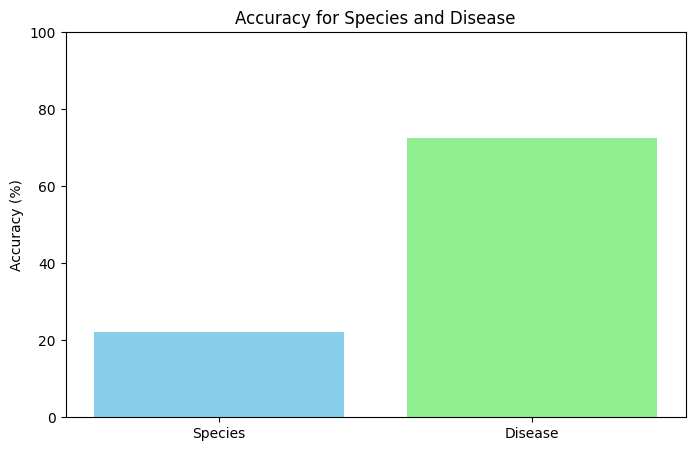

,Accuracy,Precision,Recall,F1-score
Species,22.033898,0.235074,0.220339,0.209469
Disease,72.457627,0.703204,0.724576,0.713482
Overall,47.245763,NaN,NaN,NaN


In [ ]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np # Import numpy for mean calculation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate(loader, model):
    model.eval()
    all_species, all_species_pred = [], []
    all_disease, all_disease_pred = [], []
    all_correct_both = [] # To track samples where both species and disease are correct

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            species_pred, disease_pred = model(imgs)

            species_labels = labels % num_species
            disease_labels = labels // num_species

            species_preds_argmax = torch.argmax(species_pred, dim=1)
            disease_preds_argmax = torch.argmax(disease_pred, dim=1)


            all_species.extend(species_labels.cpu().numpy())
            all_species_pred.extend(species_preds_argmax.cpu().numpy())

            all_disease.extend(disease_labels.cpu().numpy())
            all_disease_pred.extend(disease_preds_argmax.cpu().numpy())

            # Check where both predictions are correct (keeping this for now in case needed later)
            correct_species = (species_preds_argmax == species_labels)
            correct_disease = (disease_preds_argmax == disease_labels)
            correct_both = (correct_species & correct_disease)
            all_correct_both.extend(correct_both.cpu().numpy())


    # Metrics
    species_acc = accuracy_score(all_species, all_species_pred) * 100 # Convert to percentage
    disease_acc = accuracy_score(all_disease, all_disease_pred) * 100 # Convert to percentage

    # Calculate overall accuracy as the average of species and disease accuracy
    overall_acc = (species_acc + disease_acc) / 2

    sp_prec, sp_rec, sp_f1, _ = precision_recall_fscore_support(all_species, all_species_pred, average="weighted", zero_division=0)
    dis_prec, dis_rec, dis_f1, _ = precision_recall_fscore_support(all_disease, all_disease_pred, average="weighted", zero_division=0)


    results = {
        "Species": {"Accuracy": species_acc, "Precision": sp_prec, "Recall": sp_rec, "F1-score": sp_f1},
        "Disease": {"Accuracy": disease_acc, "Precision": dis_prec, "Recall": dis_rec, "F1-score": dis_f1},
        "Overall": {"Accuracy": overall_acc} # Add overall accuracy to results
    }

    # Visualization
    labels = ['Species', 'Disease']
    accuracy_values = [results['Species']['Accuracy'], results['Disease']['Accuracy']]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, accuracy_values, color=['skyblue', 'lightgreen'])
    plt.ylabel('Accuracy (%)') # Update y-axis label
    plt.title('Accuracy for Species and Disease')
    plt.ylim(0, 100) # Update y-axis limit
    plt.show()

    return results

# Path to the saved model and log
SAVE_PATH = "/content/drive/MyDrive/Models/plant_multioutput_semantic.pth"
LOG_PATH = "/content/drive/MyDrive/Models/training_log.csv"

# Check if the model exists and load it
if os.path.exists(SAVE_PATH):
    # Load the entire checkpoint dictionary
    checkpoint = torch.load(SAVE_PATH, map_location=device)
    # Load only the model's state_dict
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Loaded model state from {SAVE_PATH} for evaluation.")

    # Get the number of trained epochs from the checkpoint
    if 'epoch' in checkpoint:
        trained_epochs = checkpoint['epoch']
        print(f"Model trained for {trained_epochs} epochs.")
    else:
        print("Epoch information not found in the saved model checkpoint.")

else:
    print(f"❌ No saved model found at {SAVE_PATH}. Evaluation will use the current model in memory (if any).")


# Run evaluation on the test set
results = evaluate(test_loader, model)

# Print results in a table
results_df = pd.DataFrame(results).T
display(results_df)

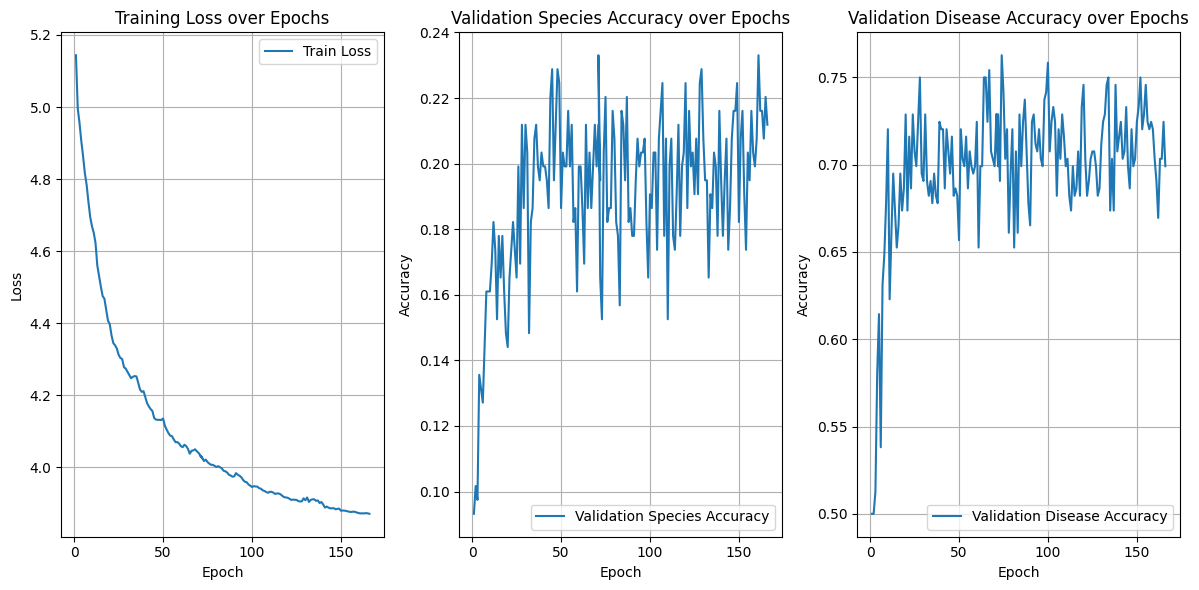

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the training log
LOG_PATH = "/content/drive/MyDrive/Models/training_log.csv"
try:
    log_df = pd.read_csv(LOG_PATH)

    # Plotting
    plt.figure(figsize=(12, 6))

    # Plot Loss
    plt.subplot(1, 3, 1)
    plt.plot(log_df['epoch'], log_df['train_loss'], label='Train Loss') # Corrected column name
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss over Epochs')
    plt.legend()
    plt.grid(True)

    # Plot Species Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(log_df['epoch'], log_df['species_val_acc'], label='Validation Species Accuracy') # Corrected column name
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Validation Species Accuracy over Epochs')
    plt.legend()
    plt.grid(True)

    # Plot Disease Accuracy
    plt.subplot(1, 3, 3)
    plt.plot(log_df['epoch'], log_df['disease_val_acc'], label='Validation Disease Accuracy') # Corrected column name
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Validation Disease Accuracy over Epochs')
    plt.legend()
    plt.grid(True)


    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Error: The log file '{LOG_PATH}' was not found. Please make sure the training process has started and the file is being created.")
except Exception as e:
    print(f"An error occurred while plotting: {e}")